# V21: Enhanced Portfolio Strategy with Transaction Fees (0.25%)

This notebook implements the full suite of portfolio strategies while accounting for **transaction fees (0.25%)**.
Strategi yang disertakan:
1. **Markowitz Only** (Static Markowitz)
2. **AI-Gated Markowitz** (Random Forest Gatekeeper)
3. **HMM-Gated Markowitz** (Gaussian HMM Gatekeeper)
4. **AI+HMM Gated** (Hierarchical Double-Layer Gate)
5. **Full Enhanced** (AI+HMM Gate + Graph MIS Filtering + Markowitz)
6. **BTC Benchmark** (Buy and Hold)

**Changes in V21:**
- **Transaction Fees:** Added a 0.25% fee per rebalance (based on weight turnover).
- High-quality visualization and Excel export preserved.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.ensemble import RandomForestClassifier
from hmmlearn import hmm
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data ---
file_path = '../dataset_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

print(f"✓ Data Loaded: {len(data)} rows")

✓ Data Loaded: 990 rows


In [2]:
# --- 2. Model Training (HMM & AI) ---
print("Training Models...")

# HMM Layer
market_log_ret = np.log1p(market_return).replace([np.inf, -np.inf], np.nan).dropna()
X_global = market_log_ret.values.reshape(-1, 1)
global_hmm = hmm.GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=42)
global_hmm.fit(X_global)
bull_state = np.argmax([global_hmm.means_[i][0] for i in range(2)])
hmm_regimes = pd.Series(global_hmm.predict(X_global) == bull_state, index=market_log_ret.index).astype(int)

# AI Layer
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()
features['Target'] = (market_return.shift(-1) > 0).astype(int)
features = features.dropna()

train_mask = (features.index.year >= 2023) & (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train, y_train = features.loc[train_mask, ['Vol_20', 'Mom_20', 'Mom_50']], features.loc[train_mask, 'Target']
X_test = features.loc[test_mask, ['Vol_20', 'Mom_20', 'Mom_50']]
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
ai_probs = pd.Series(rf_model.predict_proba(X_test)[:, 1], index=X_test.index)

print("✓ Models Trained.")

Training Models...
✓ Models Trained.


In [3]:
# --- 3. Strategy Functions ---

def get_mis_assets(returns_window, correlation_threshold=0.5):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = returns_window.columns
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.iloc[i, j]) > correlation_threshold:
                G.add_edge(assets[i], assets[j])
    mis = nx.approximation.maximum_independent_set(G)
    return list(mis)

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    mu = selected_returns.mean() * 252
    sigma = selected_returns.cov() * 252
    def neg_sharpe_ratio(weights):
        port_ret = np.sum(weights * mu)
        port_vol = np.sqrt(np.dot(weights.T, np.dot(sigma, weights)))
        return -port_ret / port_vol if port_vol > 0 else 0
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(len(mu)))
    guess = [1. / len(mu)] * len(mu)
    try:
        res = minimize(neg_sharpe_ratio, guess, method='SLSQP', bounds=bounds, constraints=constraints)
        return dict(zip(selected_returns.columns, res.x))
    except:
        return dict(zip(selected_returns.columns, guess))

def run_simulation(strategy_type, test_dates, returns, ai_probs, hmm_regimes, lookback=30, fee_rate=0.0025):
    current_value = 100.0
    history = [current_value]
    dates = [test_dates[0]]
    prev_weights = {'CASH': 1.0} # Assume starting in CASH (100% liquidity)
    
    for i, date in enumerate(test_dates[:-1]):
        # 1. Check Gates
        ai_gate = ai_probs.loc[date] > 0.5
        hmm_gate = hmm_regimes.reindex(test_dates, method='ffill').loc[date] == 1
        
        if strategy_type == 'Markowitz Only': is_bull = True
        elif strategy_type == 'AI-Gated Markowitz': is_bull = ai_gate
        elif strategy_type == 'HMM-Gated Markowitz': is_bull = hmm_gate
        elif strategy_type in ['Hierarchical MK', 'Hierarchical (AI+HMM)']: is_bull = ai_gate and hmm_gate
        elif strategy_type in ['Full Enhanced', 'Full Enhanced (AI+HMM+Graph)']: is_bull = ai_gate and hmm_gate
        else: is_bull = True
            
        # 2. Get Target Weights
        loc_idx = returns.index.get_loc(date)
        window_rets = returns.iloc[loc_idx-lookback:loc_idx]
        
        if not is_bull: 
            weights = {'CASH': 1.0}
        else:
            if 'Full Enhanced' in strategy_type:
                selected = get_mis_assets(window_rets)
                weights = optimize_markowitz(window_rets[selected])
            else:
                weights = optimize_markowitz(window_rets)
        
        # 3. Calculate Transaction Fee based on turnover
        # Turnover = sum of absolute changes in weights
        all_assets = set(weights.keys()) | set(prev_weights.keys())
        turnover = sum(abs(weights.get(a, 0) - prev_weights.get(a, 0)) for a in all_assets)
        current_value *= (1 - turnover * fee_rate)
        
        # 4. Calculate Daily Return
        next_date = test_dates[i+1]
        next_rets = returns.loc[next_date]
        
        if 'CASH' in weights:
            day_ret = 0.0
        else:
            day_ret = sum(w * next_rets[a] for a, w in weights.items())
            
        current_value *= (1 + day_ret)
        history.append(current_value)
        dates.append(next_date)
        prev_weights = weights
        
    df_res = pd.DataFrame({'Date': dates, 'Portfolio_Value': history}).set_index('Date')
    return df_res

In [4]:
# --- 4. Performance Comparison ---
test_dates = ai_probs.index
results = {}

strategies = [
    ('Markowitz Only', 'Static Markowitz'), 
    ('AI-Gated Markowitz', 'AI-Gated Markowitz (RF)'),
    ('HMM-Gated Markowitz', 'HMM-Gated Markowitz'),
    ('Hierarchical MK', 'Hierarchical (AI+HMM)'),
    ('Full Enhanced', 'Full Enhanced (AI+HMM+Graph)')
]

for strat_type, label in strategies:
    print(f"Simulating {label} (with 0.25% fees)...")
    results[label] = run_simulation(strat_type, test_dates, returns, ai_probs, hmm_regimes, fee_rate=0.0025)

# BTC Benchmark
btc_price = data.loc[test_dates, 'BTC-USD']
results['Buy and Hold (BTC)'] = pd.DataFrame({'Portfolio_Value': (btc_price / btc_price.iloc[0] * 100)}, index=test_dates)

print("✓ All simulations complete.")

Simulating Static Markowitz (with 0.25% fees)...
Simulating AI-Gated Markowitz (RF) (with 0.25% fees)...
Simulating HMM-Gated Markowitz (with 0.25% fees)...
Simulating Hierarchical (AI+HMM) (with 0.25% fees)...
Simulating Full Enhanced (AI+HMM+Graph) (with 0.25% fees)...
✓ All simulations complete.


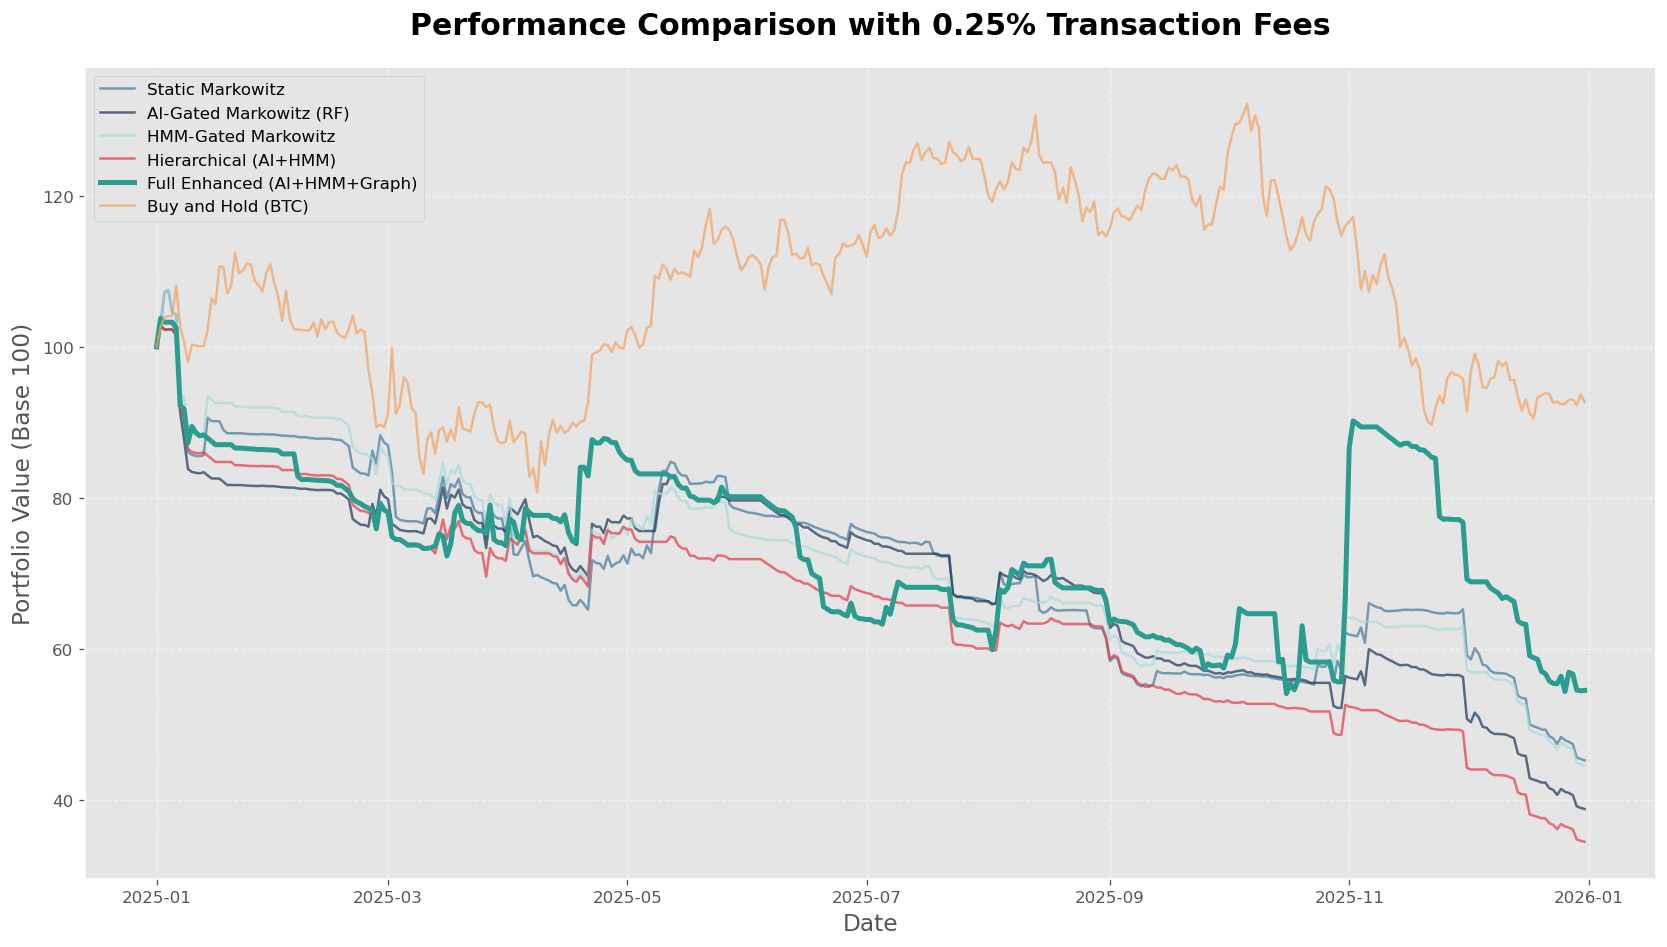

✓ Results exported to 'strategy_results_with_fees_v21.xlsx'


In [5]:
# --- 5. Visualization ---
plt.figure(figsize=(14, 8), dpi=120)

colors = {
    'Static Markowitz': '#457B9D',
    'AI-Gated Markowitz (RF)': '#1D3557',
    'HMM-Gated Markowitz': '#A8DADC',
    'Hierarchical (AI+HMM)': '#E63946',
    'Full Enhanced (AI+HMM+Graph)': '#2A9D8F',
    'Buy and Hold (BTC)': '#F4A261'
}

for label, df in results.items():
    linewidth = 3 if 'Full Enhanced' in label else 1.5
    alpha = 1.0 if 'Full Enhanced' in label else 0.7
    plt.plot(df.index, df['Portfolio_Value'], label=label, color=colors.get(label, None), linewidth=linewidth, alpha=alpha)

plt.title('Performance Comparison with 0.25% Transaction Fees', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Portfolio Value (Base 100)', fontsize=14)
plt.legend(loc='upper left', frameon=True, fontsize=10)
plt.grid(True, which='major', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('performance_with_fees.png')
plt.show()

# --- 6. Export to Excel ---
with pd.ExcelWriter('strategy_results_with_fees_v21.xlsx') as writer:
    for label, df in results.items():
        sheet_name = label[:30].replace('(', '').replace(')', '')
        df.to_excel(writer, sheet_name=sheet_name)

print("✓ Results exported to 'strategy_results_with_fees_v21.xlsx'")